# NHVSingV2 — Re-synthesis Demo

Re-synthesizes ground-truth WAV files using the exported NHVSingV2 model and compares them against the originals.

**Requirements:** Run from the repository root (`NHVSing/`).  
RMVPE model (~200 MB) is auto-downloaded on first run if not already present.

In [6]:
import sys
from pathlib import Path

import numpy as np
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

sys.path.insert(0, str(Path('.').resolve()))

CONFIG_PATH = 'config_v2.yaml'
ONNX_PATH   = 'exported_models/v2/full_vocoder.onnx'
SAMPLES = [
    ('wav/sample_wav/ground_truth_kiritan.wav', 'Touhoku Kiritan'),
    ('wav/sample_wav/ground_truth_natsume.wav', 'Natsume Yuri'),
]

In [7]:
from inference import UnifiedONNXModel, extract_features_from_wav
from dataset import norm_interp_f0
import yaml

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

onnx_model = UnifiedONNXModel(ONNX_PATH, cfg)

--- Initializing Unified ONNX Model ---
✅ Unified ONNX model loaded: exported_models/v2/full_vocoder.onnx


In [9]:
def synthesize(wav_path: str):
    """Returns (gt_wav, synth_wav, sample_rate)."""
    sr = cfg['preprocess']['sample_rate']

    gt_wav, _ = sf.read(wav_path)
    if gt_wav.ndim == 2:
        gt_wav = gt_wav.mean(axis=1)
    gt_wav = gt_wav.astype(np.float32)

    f0, log_melspc = extract_features_from_wav(Path(wav_path), cfg)
    f0, _ = norm_interp_f0(f0)

    synth = onnx_model.run(log_melspc.numpy(), f0.numpy())
    return gt_wav, synth, sr


def compute_mel(y: np.ndarray) -> np.ndarray:
    p = cfg['preprocess']
    S = librosa.feature.melspectrogram(
        y=y, sr=p['sample_rate'],
        n_fft=p['fft_size'], hop_length=p['hop_size'],
        win_length=p['hop_size'] * 4,
        n_mels=p['mel_dim'], fmin=p['mel_min'], fmax=p['mel_max'],
        center=True,
    )
    return librosa.power_to_db(S, ref=1.0)


def show(wav_path: str, title: str):
    gt_wav, synth_wav, sr = synthesize(wav_path)

    sep = '=' * 60
    print(sep)
    print(f'  {title}')
    print(sep)

    print('\n▶ Ground Truth')
    display(Audio(gt_wav, rate=sr))

    print('\n▶ Re-synthesized (NHVSingV2)')
    display(Audio(synth_wav, rate=sr))

    mel_gt    = compute_mel(gt_wav)
    mel_synth = compute_mel(synth_wav)
    T = min(mel_gt.shape[1], mel_synth.shape[1])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    fig.subplots_adjust(left=0.06, right=0.88, top=0.85, bottom=0.12, wspace=0.08)

    kw = dict(aspect='auto', origin='lower', vmin=-80, vmax=0, cmap='magma')
    im = axes[0].imshow(mel_gt[:, :T],    **kw)
    axes[1].imshow(mel_synth[:, :T], **kw)
    axes[0].set_title(f'{title} — Ground Truth')
    axes[1].set_title(f'{title} — Re-synthesized')
    for ax in axes:
        ax.set_xlabel('Frame')
    axes[0].set_ylabel('Mel bin')

    cax = fig.add_axes([0.90, 0.12, 0.015, 0.73])
    fig.colorbar(im, cax=cax, label='dB')

    plt.show()

--- Extracting features from WAV ---
  RMS normalized to 0.083 (active RMS was 0.0845)
✅ Feature extraction complete (rmvpe). Frames: 4475
  Touhoku Kiritan

▶ Ground Truth



▶ Re-synthesized (NHVSingV2)


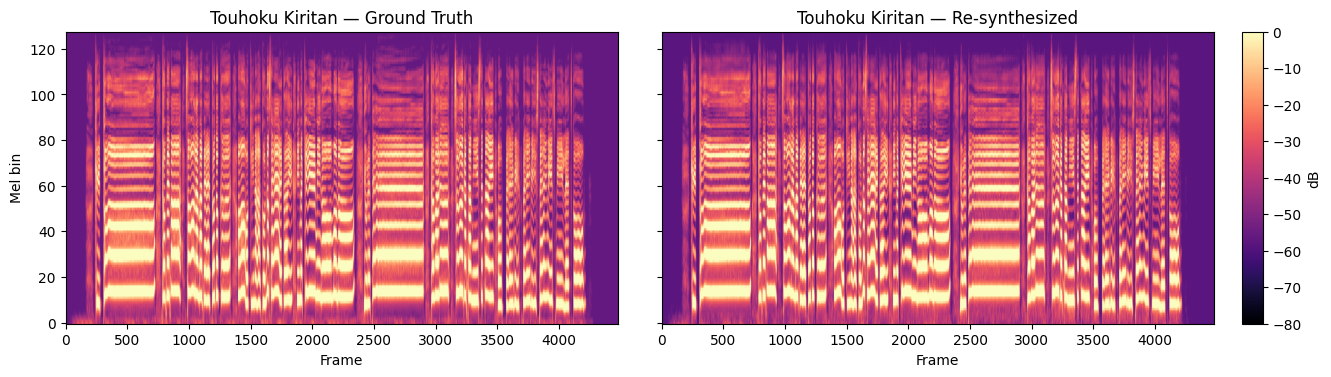

In [10]:
show(*SAMPLES[0])  # Touhoku Kiritan

--- Extracting features from WAV ---
  RMS normalized to 0.083 (active RMS was 0.0308)
✅ Feature extraction complete (rmvpe). Frames: 1335
  Natsume Yuri

▶ Ground Truth



▶ Re-synthesized (NHVSingV2)


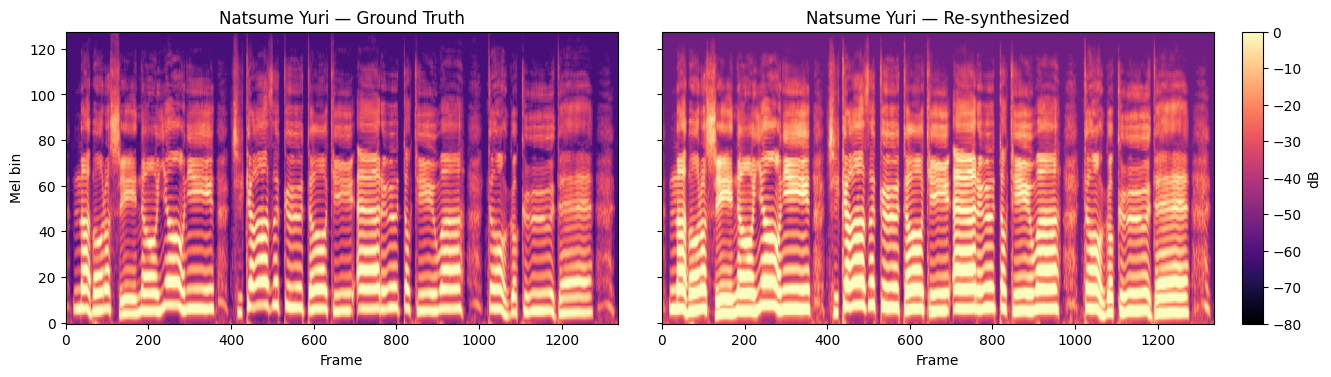

In [11]:
show(*SAMPLES[1])  # Natsume Yuri